In [1]:
import subprocess
subprocess.run(["pip", "install", "nltk", "datasets"])
print("✅ Done!")

✅ Done!


In [2]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
print("✅ NLTK ready!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\katta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\katta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\katta\AppData\Roaming\nltk_data...


✅ NLTK ready!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset automatically
from datasets import load_dataset
print("Downloading IMDB dataset... please wait ⏳")
dataset = load_dataset("imdb")
df = pd.DataFrame(dataset["train"])
df["sentiment"] = df["label"].map({1:"positive", 0:"negative"})
print("✅ Dataset loaded!")
print("Shape:", df.shape)
print(df["sentiment"].value_counts())
print(df.head())

README.md: 0.00B [00:00, ?B/s]

C:\Users\katta\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\katta\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Dataset loaded!
Shape: (25000, 3)
sentiment
negative    12500
positive    12500
Name: count, dtype: int64
                                                text  label sentiment
0  I rented I AM CURIOUS-YELLOW from my video sto...      0  negative
1  "I Am Curious: Yellow" is a risible and preten...      0  negative
2  If only to avoid making this type of film in t...      0  negative
3  This film was probably inspired by Godard's Ma...      0  negative
4  Oh, brother...after hearing about this ridicul...      0  negative


In [4]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

print("Cleaning reviews... please wait ⏳")
df["clean_text"] = df["text"].apply(clean_text)
print("✅ Cleaning done!")
print(df["clean_text"].iloc[0][:200])

Cleaning reviews... please wait ⏳
✅ Cleaning done!
rented curious yellow video store controversy surrounded first released also heard first seized custom ever tried enter country therefore fan film considered controversial really see plot centered aro


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
predictions = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, predictions)
print(f"✅ Model trained!")
print(f"Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, predictions,
      target_names=["Negative","Positive"]))

✅ Model trained!
Accuracy: 89.20%
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      2515
    Positive       0.88      0.91      0.89      2485

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



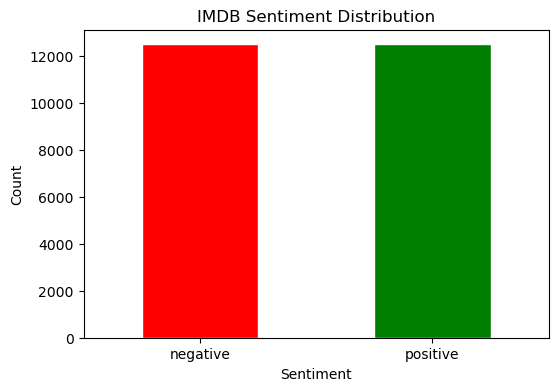

Review: This movie was absolutely amazing!...
Prediction: POSITIVE 😊 (74.1% confident)

Review: Terrible film, complete waste of time!...
Prediction: NEGATIVE 😞 (98.4% confident)

Review: One of the best movies I have ever seen!...
Prediction: POSITIVE 😊 (96.4% confident)

🎉 Sentiment Analysis Project Complete!


In [6]:
# Sentiment distribution chart
df["sentiment"].value_counts().plot(
    kind="bar", color=["red","green"],
    figsize=(6,4), edgecolor="white")
plt.title("IMDB Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig("sentiment_result.png")
plt.show()

# Live prediction demo
def predict_sentiment(review):
    cleaned = clean_text(review)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "POSITIVE 😊" if pred==1 else "NEGATIVE 😞"
    print(f"Review: {review[:60]}...")
    print(f"Prediction: {label} ({max(prob)*100:.1f}% confident)\n")

predict_sentiment("This movie was absolutely amazing!")
predict_sentiment("Terrible film, complete waste of time!")
predict_sentiment("One of the best movies I have ever seen!")
print("🎉 Sentiment Analysis Project Complete!")